# Synthetic phantom плеврального скольжения

Цель notebook — проверить **представление и метрики** axis-safe phantom v2.1, необходимые будущему registration-кандидату S1.

Phantom задаёт два известных поля `expiration → inspiration`:

- поле лёгкого;
- поле грудной стенки;
- одинаковую нормальную компоненту около плевры;
- известное тангенциальное скольжение лёгкого относительно стенки.

Азимутальная компонента непрерывно затухает к оси вращения: это устраняет нефизичную сингулярность исторического v2.0. Это не результат регистрации человека и не доказательство работоспособности S1. Будущий алгоритм должен будет восстановить эти скрытые поля только по изображениям.


**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import subprocess
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

source_root = str(REPO_ROOT / "src")
if source_root not in sys.path:
    sys.path.insert(0, source_root)

In [3]:
from breathgeom.measure.sliding_phantom import (
    SlidingPhantomParams,
    evaluate_sliding_interface,
    make_sliding_phantom,
)

params = SlidingPhantomParams()
phantom = make_sliding_phantom(params)
reference = evaluate_sliding_interface(phantom)
missing_body_motion = evaluate_sliding_interface(
    phantom,
    body_displacement_mm=np.zeros_like(phantom.body_displacement_mm),
)
artificially_glued = evaluate_sliding_interface(
    phantom,
    body_displacement_mm=phantom.lung_displacement_mm,
)
indices = np.indices(phantom.image.shape, dtype=np.float64)
centre = (np.asarray(phantom.image.shape, dtype=np.float64) - 1.0) / 2.0
coordinates = (np.moveaxis(indices, 0, -1) - centre) * np.asarray(phantom.spacing_mm)
cylindrical_level = np.sqrt(
    np.square(coordinates[..., 0] / phantom.lung_radii_mm[0])
    + np.square(coordinates[..., 1] / phantom.lung_radii_mm[1])
)
normal_component = np.sum(
    phantom.lung_displacement_mm * phantom.interface_normal,
    axis=-1,
)
tangential_magnitude = np.linalg.norm(
    phantom.lung_displacement_mm
    - normal_component[..., None] * phantom.interface_normal,
    axis=-1,
)
near_axis = phantom.lung_mask & (cylindrical_level < 0.1)
axis_tangent_max_mm = float(np.max(tangential_magnitude[near_axis]))
axis_tangent_bound_mm = (
    params.tangential_slip_mm
    * 0.1
    / params.tangential_full_slip_radius_fraction
)

print("Используются только детерминированные synthetic arrays; медицинские данные не загружаются.")
display(pd.DataFrame([asdict(params)]).T.rename(columns={0: "Значение"}))

Используются только детерминированные synthetic arrays; медицинские данные не загружаются.


,Значение
shape,"(72, 72, 72)"
spacing_mm,"(1.0, 1.0, 1.0)"
lung_radii_mm,"(16.0, 16.0, 22.0)"
body_radii_mm,"(31.0, 29.0, 33.0)"
normal_motion_mm,3.0
tangential_slip_mm,4.0
tangential_pattern,azimuthal
tangential_ramp_mode,cylindrical_axis_safe
tangential_full_slip_radius_fraction,0.75
interface_band_mm,1.0


## Численные инварианты

Правильное multi-region представление должно одновременно сохранять контакт по нормали, разрешать тангенциальное скольжение, непрерывно затухать у оси азимутального поля и не создавать folding внутри каждой анатомической области. Jacobian через сам разрыв поля не интерпретируется как Jacobian ткани.


In [4]:
scenario_metrics = pd.DataFrame(
    [
        {"Сценарий": "Известное multi-region поле", **asdict(reference)},
        {"Сценарий": "Нет движения стенки", **asdict(missing_body_motion)},
        {"Сценарий": "Лёгкое искусственно приклеено", **asdict(artificially_glued)},
    ]
).set_index("Сценарий")
display(scenario_metrics.round(4))

checks = pd.Series(
    {
        "Нормальный mismatch p95 ≤ 0.25 мм": reference.normal_mismatch_p95_mm <= 0.25,
        "Ошибка median slip ≤ 0.25 мм": abs(
            reference.tangential_slip_median_mm - params.tangential_slip_mm
        )
        <= 0.25,
        "Lung Jacobian p01 ≥ 0.10": reference.lung_jacobian_p01 >= 0.10,
        "Body Jacobian p01 ≥ 0.10": reference.body_jacobian_p01 >= 0.10,
        "Нет folding внутри лёгкого": (reference.lung_nonpositive_jacobian_fraction == 0.0),
        "Нет folding внутри стенки": (reference.body_nonpositive_jacobian_fraction == 0.0),
        "Тангенциальное поле затухает у оси": (
            axis_tangent_max_mm <= axis_tangent_bound_mm + 1e-6
        ),
    },
    name="PASS",
)
display(checks.to_frame())

,interface_voxel_count,normal_mismatch_mean_mm,normal_mismatch_p95_mm,tangential_slip_median_mm,tangential_slip_p95_mm,lung_jacobian_p01,lung_nonpositive_jacobian_fraction,body_jacobian_p01,body_nonpositive_jacobian_fraction
Сценарий,,,,,,,,,
Известное multi-region поле,8808,0.0,0.0,4.0,4.0,1.3603,0.0,0.9611,0.0
Нет движения стенки,8808,3.0,3.0,4.0,4.0,1.3603,0.0,1.0000,0.0
Лёгкое искусственно приклеено,8808,0.0,0.0,0.0,0.0,1.3603,0.0,1.1715,0.0


,PASS
Нормальный mismatch p95 ≤ 0.25 мм,True
Ошибка median slip ≤ 0.25 мм,True
Lung Jacobian p01 ≥ 0.10,True
Body Jacobian p01 ≥ 0.10,True
Нет folding внутри лёгкого,True
Нет folding внутри стенки,True
Тангенциальное поле затухает у оси,True


## Геометрия и два поля

Стрелки внутри лёгкого содержат радиальное движение и вращательную тангенциальную компоненту. В стенке остаётся нормальное движение, поэтому направления по разные стороны плевры не обязаны совпадать.


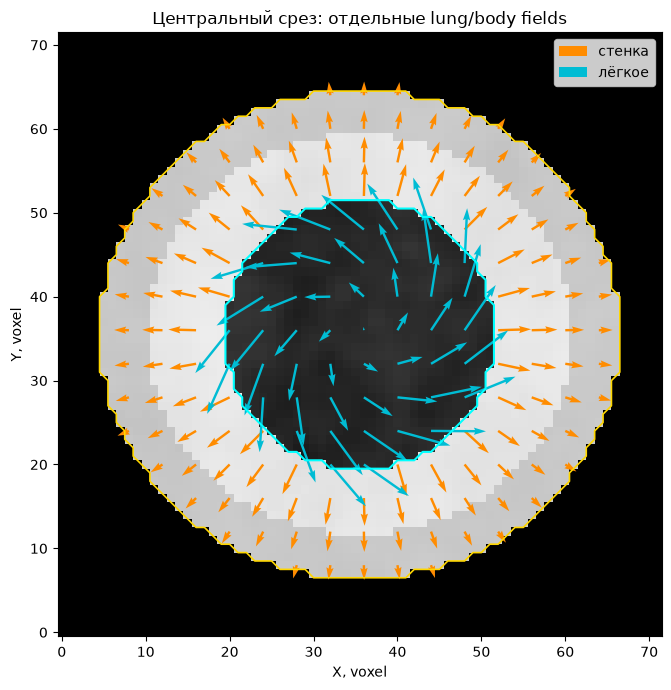

In [5]:
z_index = phantom.image.shape[2] // 2
image = phantom.image[:, :, z_index].T
lung = phantom.lung_mask[:, :, z_index].T
body = phantom.body_mask[:, :, z_index].T
lung_field = phantom.lung_displacement_mm[:, :, z_index, :]
body_field = phantom.body_displacement_mm[:, :, z_index, :]

x = np.arange(phantom.image.shape[0])
y = np.arange(phantom.image.shape[1])
x_grid, y_grid = np.meshgrid(x, y, indexing="xy")
stride = 4

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(image, cmap="gray", origin="lower", vmin=-1000, vmax=150)
ax.contour(body.astype(float), levels=[0.5], colors=["gold"], linewidths=1.2)
ax.contour(lung.astype(float), levels=[0.5], colors=["cyan"], linewidths=1.5)

lung_u = np.where(lung, lung_field[..., 0].T, np.nan)
lung_v = np.where(lung, lung_field[..., 1].T, np.nan)
wall = body & ~lung
body_u = np.where(wall, body_field[..., 0].T, np.nan)
body_v = np.where(wall, body_field[..., 1].T, np.nan)
sample = np.s_[::stride, ::stride]
ax.quiver(
    x_grid[sample],
    y_grid[sample],
    body_u[sample],
    body_v[sample],
    color="#ff8c00",
    scale=55,
    width=0.004,
    label="стенка",
)
ax.quiver(
    x_grid[sample],
    y_grid[sample],
    lung_u[sample],
    lung_v[sample],
    color="#00bcd4",
    scale=55,
    width=0.004,
    label="лёгкое",
)
ax.set_title("Центральный срез: отдельные lung/body fields")
ax.set_xlabel("X, voxel")
ax.set_ylabel("Y, voxel")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Компоненты движения около плевры

`q=1` — плевральный интерфейс. Нормальные компоненты двух полей совпадают в контрольной полосе; тангенциальная компонента лёгкого равна заданным 4 мм, а стенка не обязана следовать за ней.


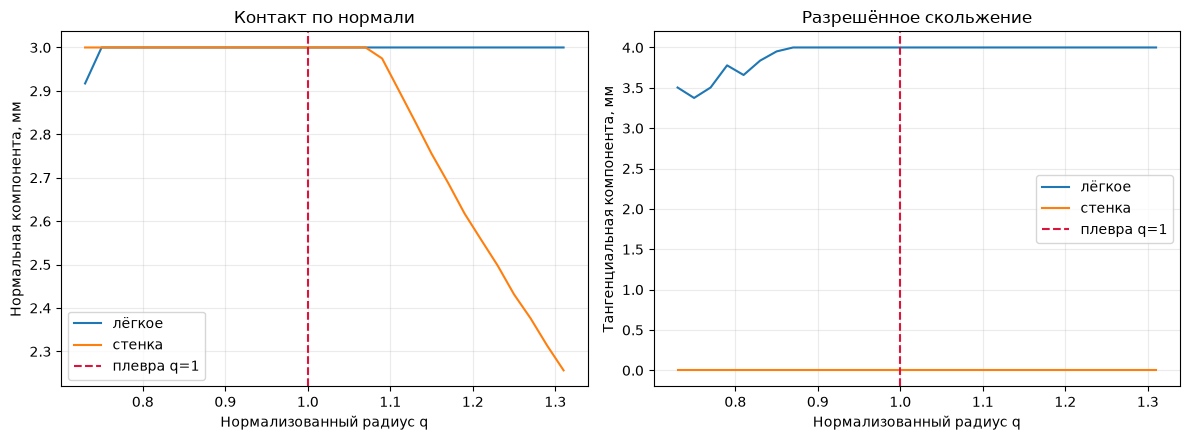

In [6]:
normal = phantom.interface_normal
tangent = phantom.interface_tangent
q = phantom.lung_level_set
lung_normal = np.sum(phantom.lung_displacement_mm * normal, axis=-1)
body_normal = np.sum(phantom.body_displacement_mm * normal, axis=-1)
lung_tangent = np.sum(phantom.lung_displacement_mm * tangent, axis=-1)
body_tangent = np.sum(phantom.body_displacement_mm * tangent, axis=-1)

bins = np.linspace(0.72, 1.32, 31)
centres = 0.5 * (bins[:-1] + bins[1:])


def binned_median(values):
    return np.asarray(
        [
            np.median(values[(q >= left) & (q < right) & phantom.body_mask])
            for left, right in zip(bins[:-1], bins[1:], strict=True)
        ]
    )


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
axes[0].plot(centres, binned_median(lung_normal), label="лёгкое")
axes[0].plot(centres, binned_median(body_normal), label="стенка")
axes[0].set_ylabel("Нормальная компонента, мм")
axes[0].set_title("Контакт по нормали")

axes[1].plot(centres, binned_median(lung_tangent), label="лёгкое")
axes[1].plot(centres, binned_median(body_tangent), label="стенка")
axes[1].set_ylabel("Тангенциальная компонента, мм")
axes[1].set_title("Разрешённое скольжение")

for ax in axes:
    ax.axvline(1.0, color="crimson", linestyle="--", label="плевра q=1")
    ax.set_xlabel("Нормализованный радиус q")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Отрицательные контроли

Метрики должны различать два разных дефекта: потерю нормального контакта и искусственное приклеивание тангенциального движения.


,Известное поле,Нет движения стенки,Искусственно приклеено
"Normal mismatch p95, мм",0.0,3.0,0.0
"Tangential slip median, мм",4.0,4.0,0.0


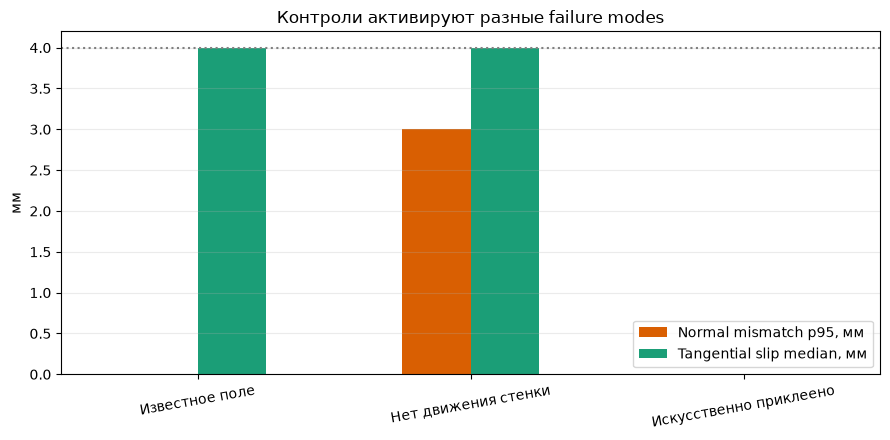

In [7]:
control_table = pd.DataFrame(
    {
        "Известное поле": [
            reference.normal_mismatch_p95_mm,
            reference.tangential_slip_median_mm,
        ],
        "Нет движения стенки": [
            missing_body_motion.normal_mismatch_p95_mm,
            missing_body_motion.tangential_slip_median_mm,
        ],
        "Искусственно приклеено": [
            artificially_glued.normal_mismatch_p95_mm,
            artificially_glued.tangential_slip_median_mm,
        ],
    },
    index=["Normal mismatch p95, мм", "Tangential slip median, мм"],
)
display(control_table.round(3))

ax = control_table.T.plot.bar(figsize=(9, 4.5), color=["#d95f02", "#1b9e77"])
ax.axhline(params.tangential_slip_mm, color="gray", linestyle=":")
ax.set_ylabel("мм")
ax.set_title("Контроли активируют разные failure modes")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Provenance и итог


In [8]:
module_path = REPO_ROOT / "src/breathgeom/measure/sliding_phantom.py"
digest = hashlib.sha256(module_path.read_bytes()).hexdigest().upper()
code_version = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
display(
    pd.DataFrame(
        [
            {"Параметр": "phantom_version", "Значение": "v2.1-axis-safe"},
            {"Параметр": "code_version", "Значение": code_version},
            {"Параметр": "module_sha256", "Значение": digest},
            {"Параметр": "coordinate_basis", "Значение": phantom.coordinate_basis},
            {"Параметр": "direction", "Значение": phantom.transform_direction},
        ]
    )
)

if checks.all():
    verdict = (
        "## Итог: synthetic representation gate пройден\n\n"
        "Multi-region ground truth сохраняет нормальный контакт, заданное "
        "тангенциальное скольжение, затухание у оси и положительный Jacobian "
        "внутри обеих областей. "
        "Отрицательные контроли распознаются разными метриками.\n\n"
        "**Это разрешает перейти к реализации S1, но не к парным картам "
        "человека.** S1 должен восстановить скрытые поля из synthetic изображений "
        "и пройти те же проверки; после этого остаются реальные Gate 1L и Gate 1B.\n"
    )
else:
    verdict = "## Итог: synthetic representation gate провален\n\nПереход к S1 заблокирован."
display(Markdown(verdict))

,Параметр,Значение
0,phantom_version,v2.1-axis-safe
1,code_version,8be5658ac56ede974c30e50551e63d891e29cc3a
2,module_sha256,6F5B563D9138F0B00F5FBEE013D3BBD456981372BB6B0B...
3,coordinate_basis,local-zero-origin-RAS+_mm
4,direction,fixed-expiration_to_moving-inspiration


## Итог: synthetic representation gate пройден

Multi-region ground truth сохраняет нормальный контакт, заданное тангенциальное скольжение, затухание у оси и положительный Jacobian внутри обеих областей. Отрицательные контроли распознаются разными метриками.

**Это разрешает перейти к реализации S1, но не к парным картам человека.** S1 должен восстановить скрытые поля из synthetic изображений и пройти те же проверки; после этого остаются реальные Gate 1L и Gate 1B.
